# 04 — Portfolio Construction Backtest

Walk-forward comparison of four weighting methods × vol-targeting on/off vs SPY buy-and-hold.

All strategies: Top-5 assets, 200DMA filter, 10bp one-way cost, monthly rebalance.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from src.data import load_prices, compute_returns, load_risk_free_rate
from src.signals import load_signals
from src.backtest import run_all_backtests, compute_metrics, print_summary, load_backtest_returns

plt.rcParams.update({'figure.dpi': 120})
PROC = '../data/processed'

prices  = load_prices(PROC)
returns = compute_returns(prices)
signals = load_signals(PROC)
rf_daily   = load_risk_free_rate(PROC)
rf_monthly = (1 + rf_daily).resample('ME').prod() - 1

# Load pre-computed returns
ret_df  = load_backtest_returns(PROC)
results = {col: {'returns': ret_df[col].dropna()} for col in ret_df.columns}
for k in results:
    results[k]['metrics'] = compute_metrics(results[k]['returns'], rf_monthly)

print('Strategies:', list(results.keys()))
summary = print_summary(results)

Strategies: ['SPY B&H', 'A: Equal', 'A: Equal + VT', 'B: Inv Vol', 'B: Inv Vol + VT', 'C: Risk Parity', 'C: Risk Parity + VT', 'D: HRP', 'D: HRP + VT']

  BACKTEST SUMMARY  (Top-5, 200DMA filter, 10bp cost, 10% vol target where applied)
                     Ann Return %  Ann Vol %  Sharpe  Sortino  Max DD %  Calmar  Hit Rate %
Strategy                                                                                   
SPY B&H                     11.54      14.90   0.658    0.887    -50.78   0.227        66.5
A: Equal                     9.66      13.66   0.580    0.780    -29.65   0.326        66.3
A: Equal + VT                7.91      10.61   0.582    0.787    -23.65   0.334        66.7
B: Inv Vol                  10.69      10.42   0.859    1.201    -15.55   0.688        69.0
B: Inv Vol + VT              8.49       8.44   0.801    1.126    -14.93   0.569        67.4
C: Risk Parity              10.85      10.43   0.874    1.242    -14.40   0.753        69.0
C: Risk Parity + VT        

---
## Colour palette

In [2]:
COLORS = {
    'SPY B&H':            '#999999',
    'A: Equal':           '#4C72B0',
    'A: Equal + VT':      '#4C72B0',
    'B: Inv Vol':         '#55A868',
    'B: Inv Vol + VT':    '#55A868',
    'C: Risk Parity':     '#C44E52',
    'C: Risk Parity + VT':'#C44E52',
    'D: HRP':             '#8172B2',
    'D: HRP + VT':        '#8172B2',
}
LS = {k: '-' if '+' not in k else '--' for k in COLORS}
LS['SPY B&H'] = ':'

---
## 1. Equity curves — all strategies

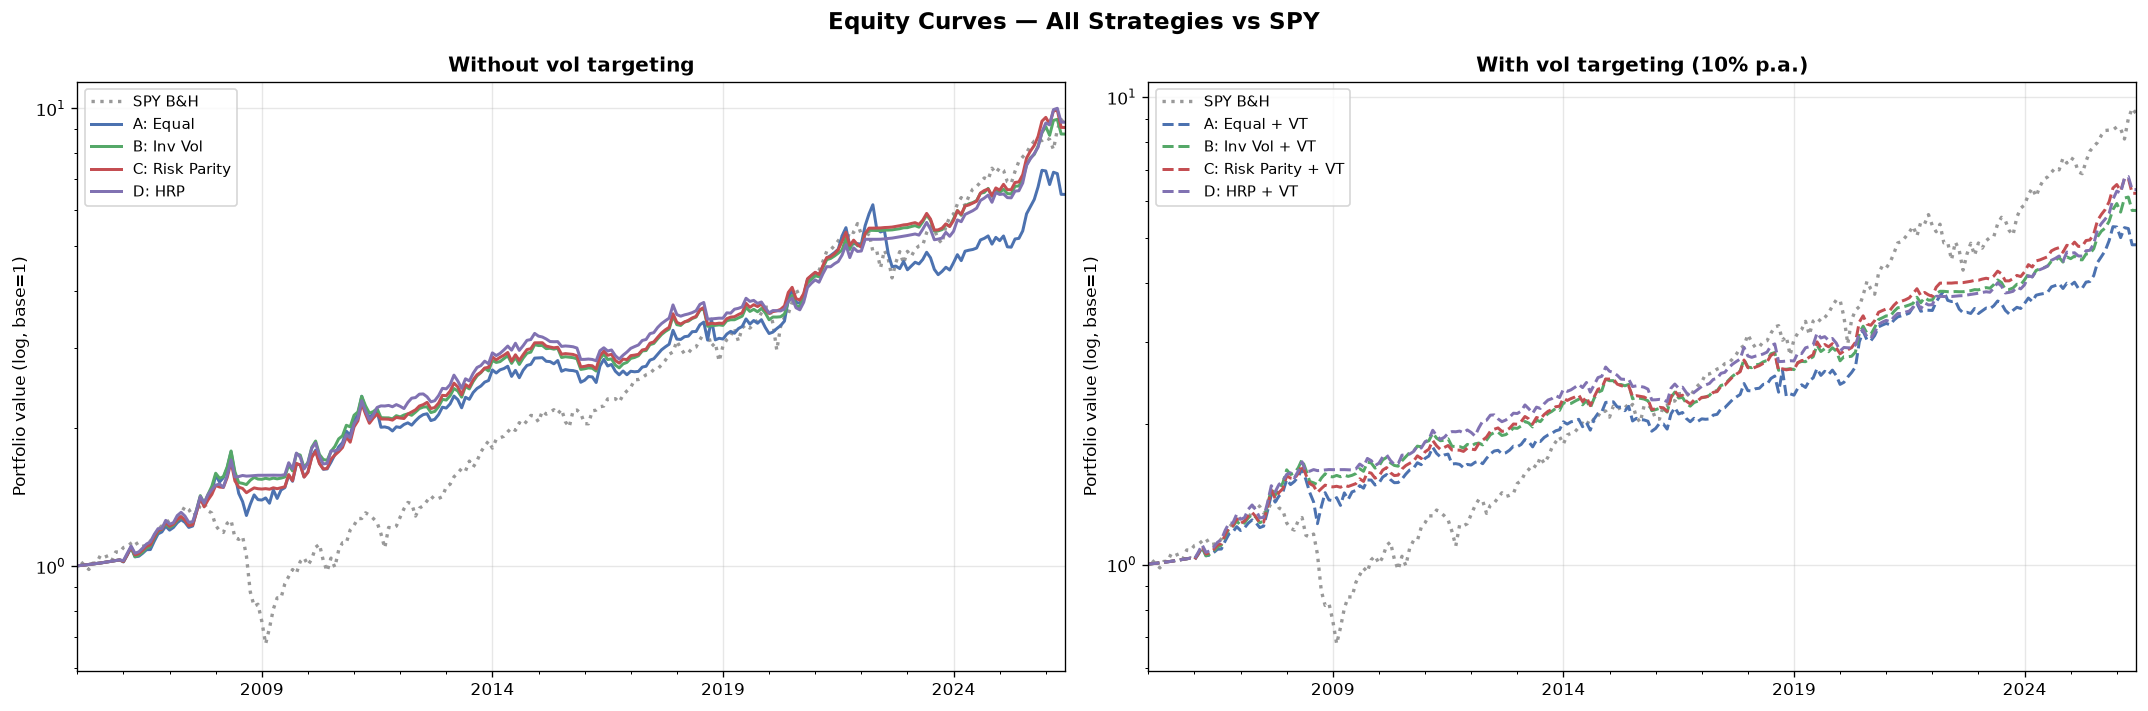

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, include_vt, title in [
    (axes[0], False, 'Without vol targeting'),
    (axes[1], True,  'With vol targeting (10% p.a.)'),
]:
    for label, res in results.items():
        if label == 'SPY B&H':
            (1 + res['returns']).cumprod().plot(ax=ax, label=label,
                color=COLORS[label], linestyle=':', linewidth=2)
            continue
        is_vt = '+ VT' in label
        if is_vt != include_vt:
            continue
        (1 + res['returns']).cumprod().plot(
            ax=ax, label=label,
            color=COLORS[label], linestyle=LS[label], linewidth=1.8)

    ax.set_yscale('log')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Portfolio value (log, base=1)')

plt.suptitle('Equity Curves — All Strategies vs SPY', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Drawdown comparison

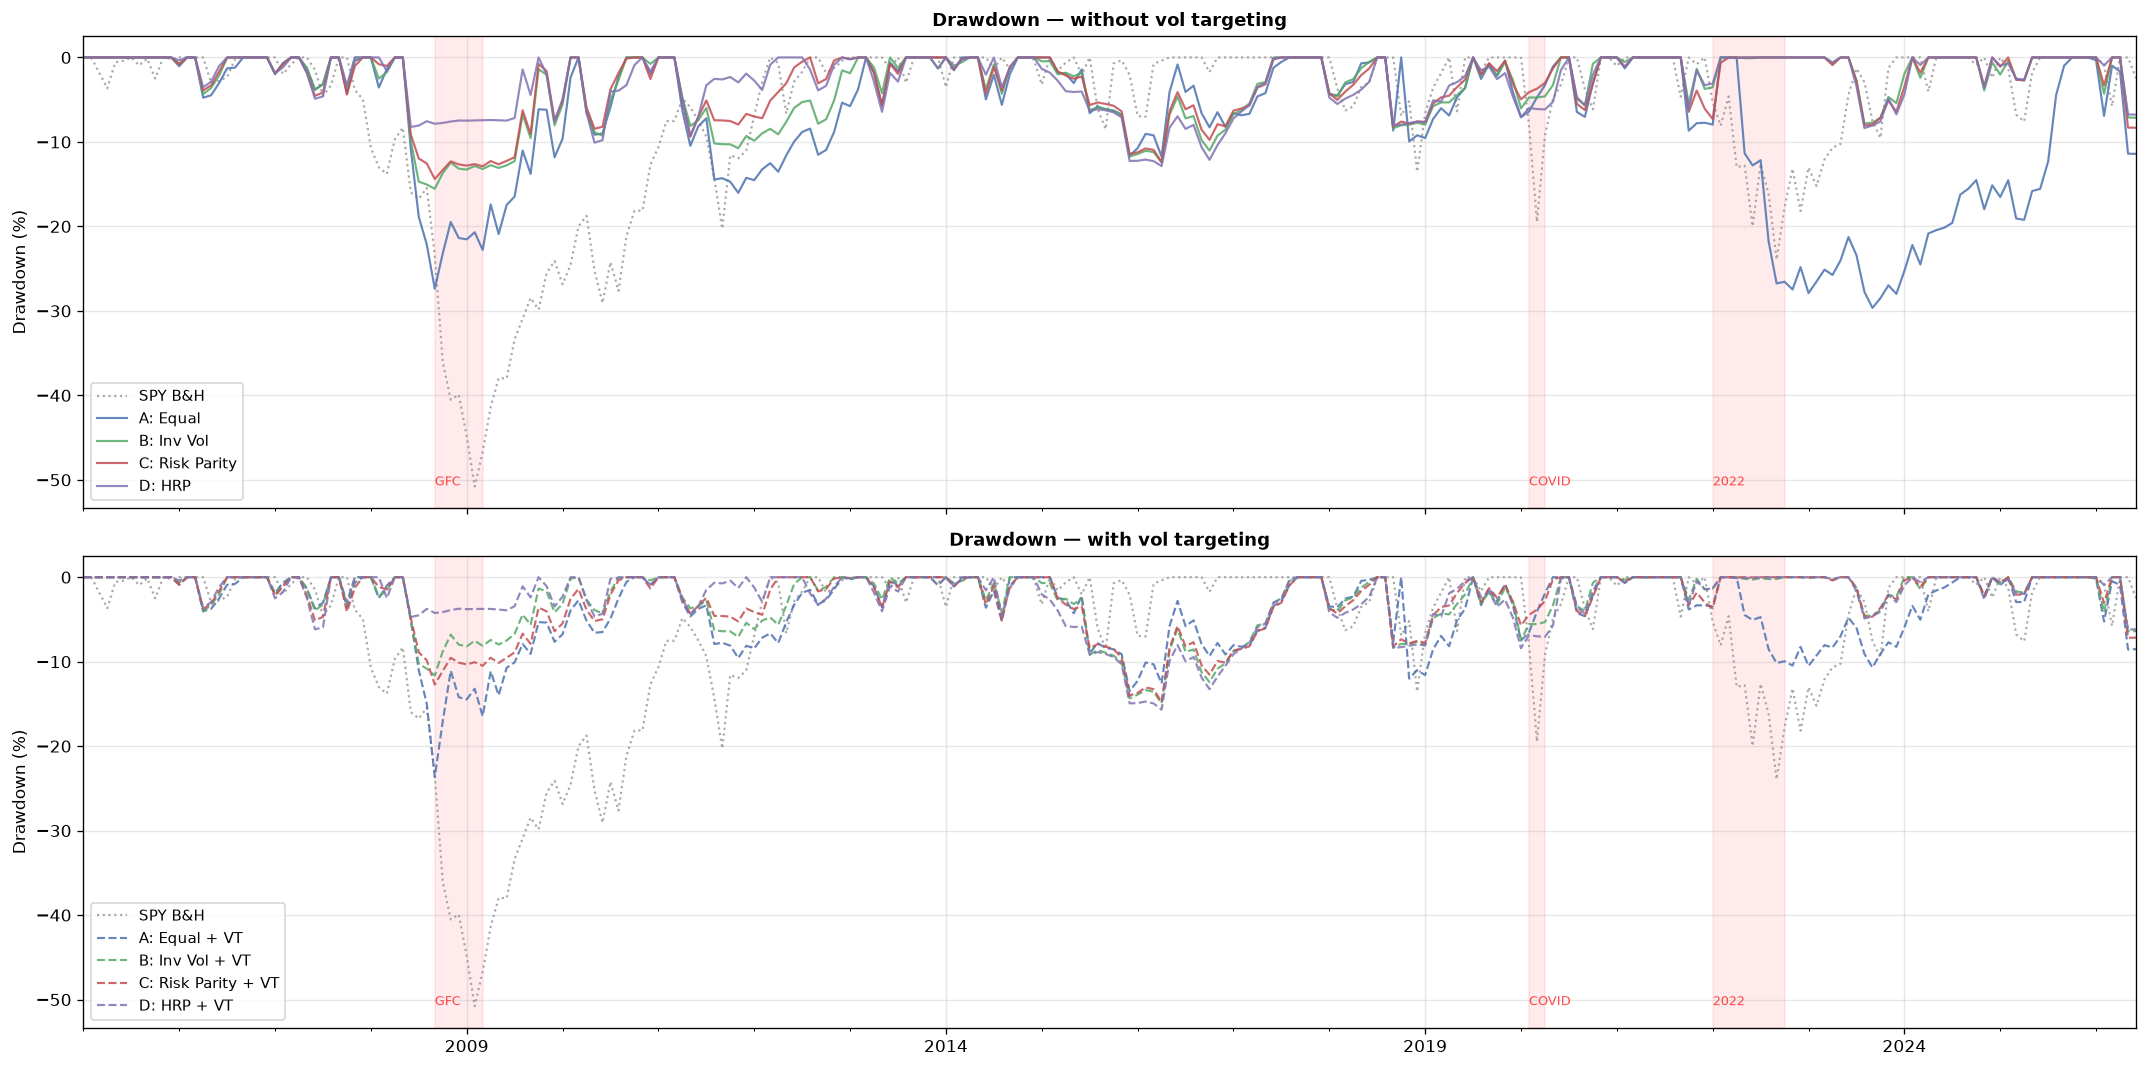

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

for ax, include_vt, title in [
    (axes[0], False, 'Drawdown — without vol targeting'),
    (axes[1], True,  'Drawdown — with vol targeting'),
]:
    for label, res in results.items():
        if label != 'SPY B&H' and ('+ VT' in label) != include_vt:
            continue
        eq = (1 + res['returns']).cumprod()
        dd = (eq / eq.cummax() - 1) * 100
        dd.plot(ax=ax, label=label,
                color=COLORS[label], linestyle=LS[label], linewidth=1.3, alpha=0.85)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Drawdown (%)')

    # Shade crisis periods
    for period, (s, e) in [('GFC', ('2008-09', '2009-03')),
                             ('COVID', ('2020-02', '2020-04')),
                             ('2022', ('2022-01', '2022-10'))]:
        ax.axvspan(s, e, alpha=0.08, color='red')
        ax.text(s, ax.get_ylim()[0] * 0.95, period, fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 3. Risk–return scatter

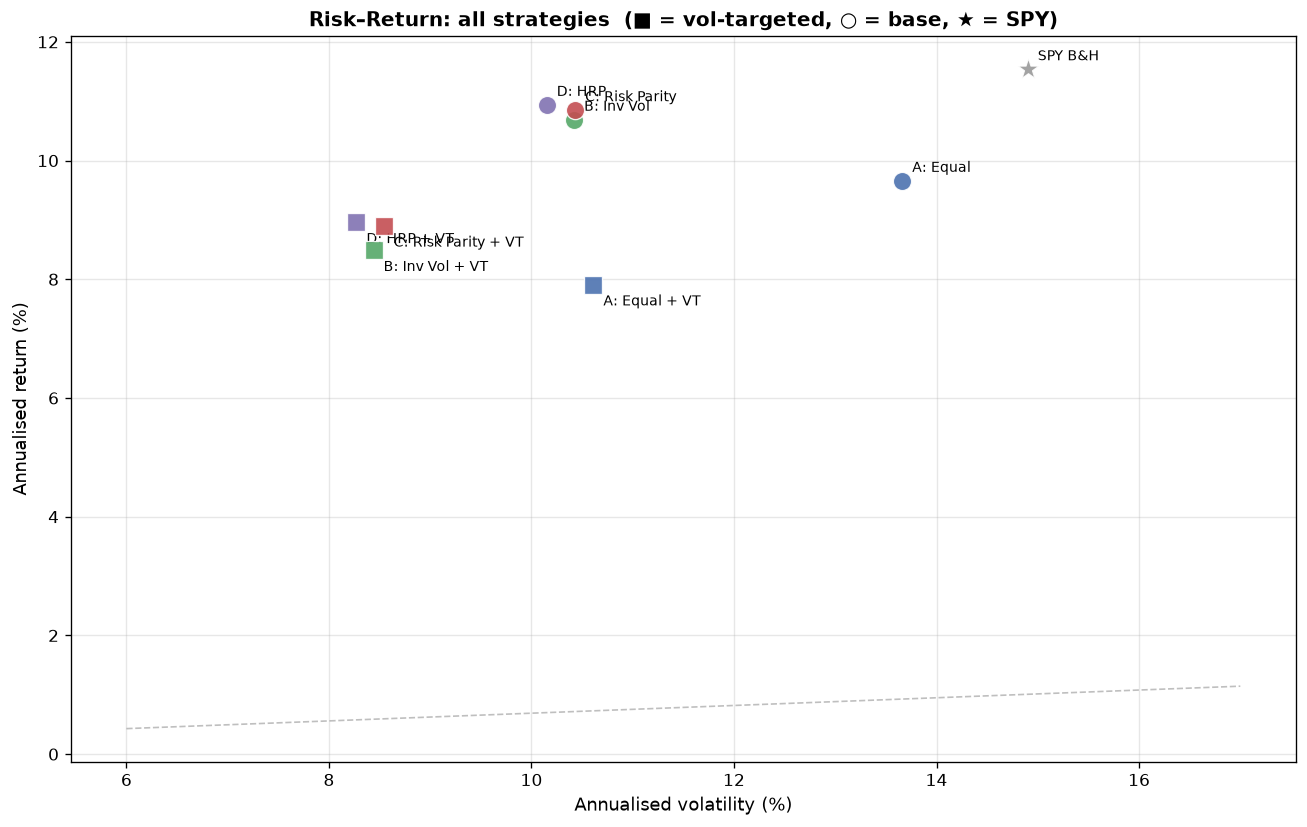

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))

for label, res in results.items():
    m   = res['metrics']
    vol = m['Ann Vol %']
    ret = m['Ann Return %']
    mdd = m['Max DD %']
    is_vt = '+ VT' in label
    marker = 's' if is_vt else ('*' if label == 'SPY B&H' else 'o')
    size   = 180 if label == 'SPY B&H' else 120
    ax.scatter(vol, ret, color=COLORS[label], marker=marker, s=size,
               alpha=0.9, zorder=5, edgecolors='white', linewidth=0.8)
    offset = (0.1, 0.15) if not is_vt else (0.1, -0.35)
    ax.annotate(label, (vol, ret), xytext=(vol + offset[0], ret + offset[1]),
                fontsize=8.5)

# Capital market line (rough)
vols = np.linspace(6, 17, 100)
ax.plot(vols, 0.04 + vols * 0.065, color='grey', linewidth=1, linestyle='--', alpha=0.5, label='CML approx')

ax.set_xlabel('Annualised volatility (%)', fontsize=11)
ax.set_ylabel('Annualised return (%)', fontsize=11)
ax.set_title('Risk–Return: all strategies  (■ = vol-targeted, ○ = base, ★ = SPY)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Key metric bar charts

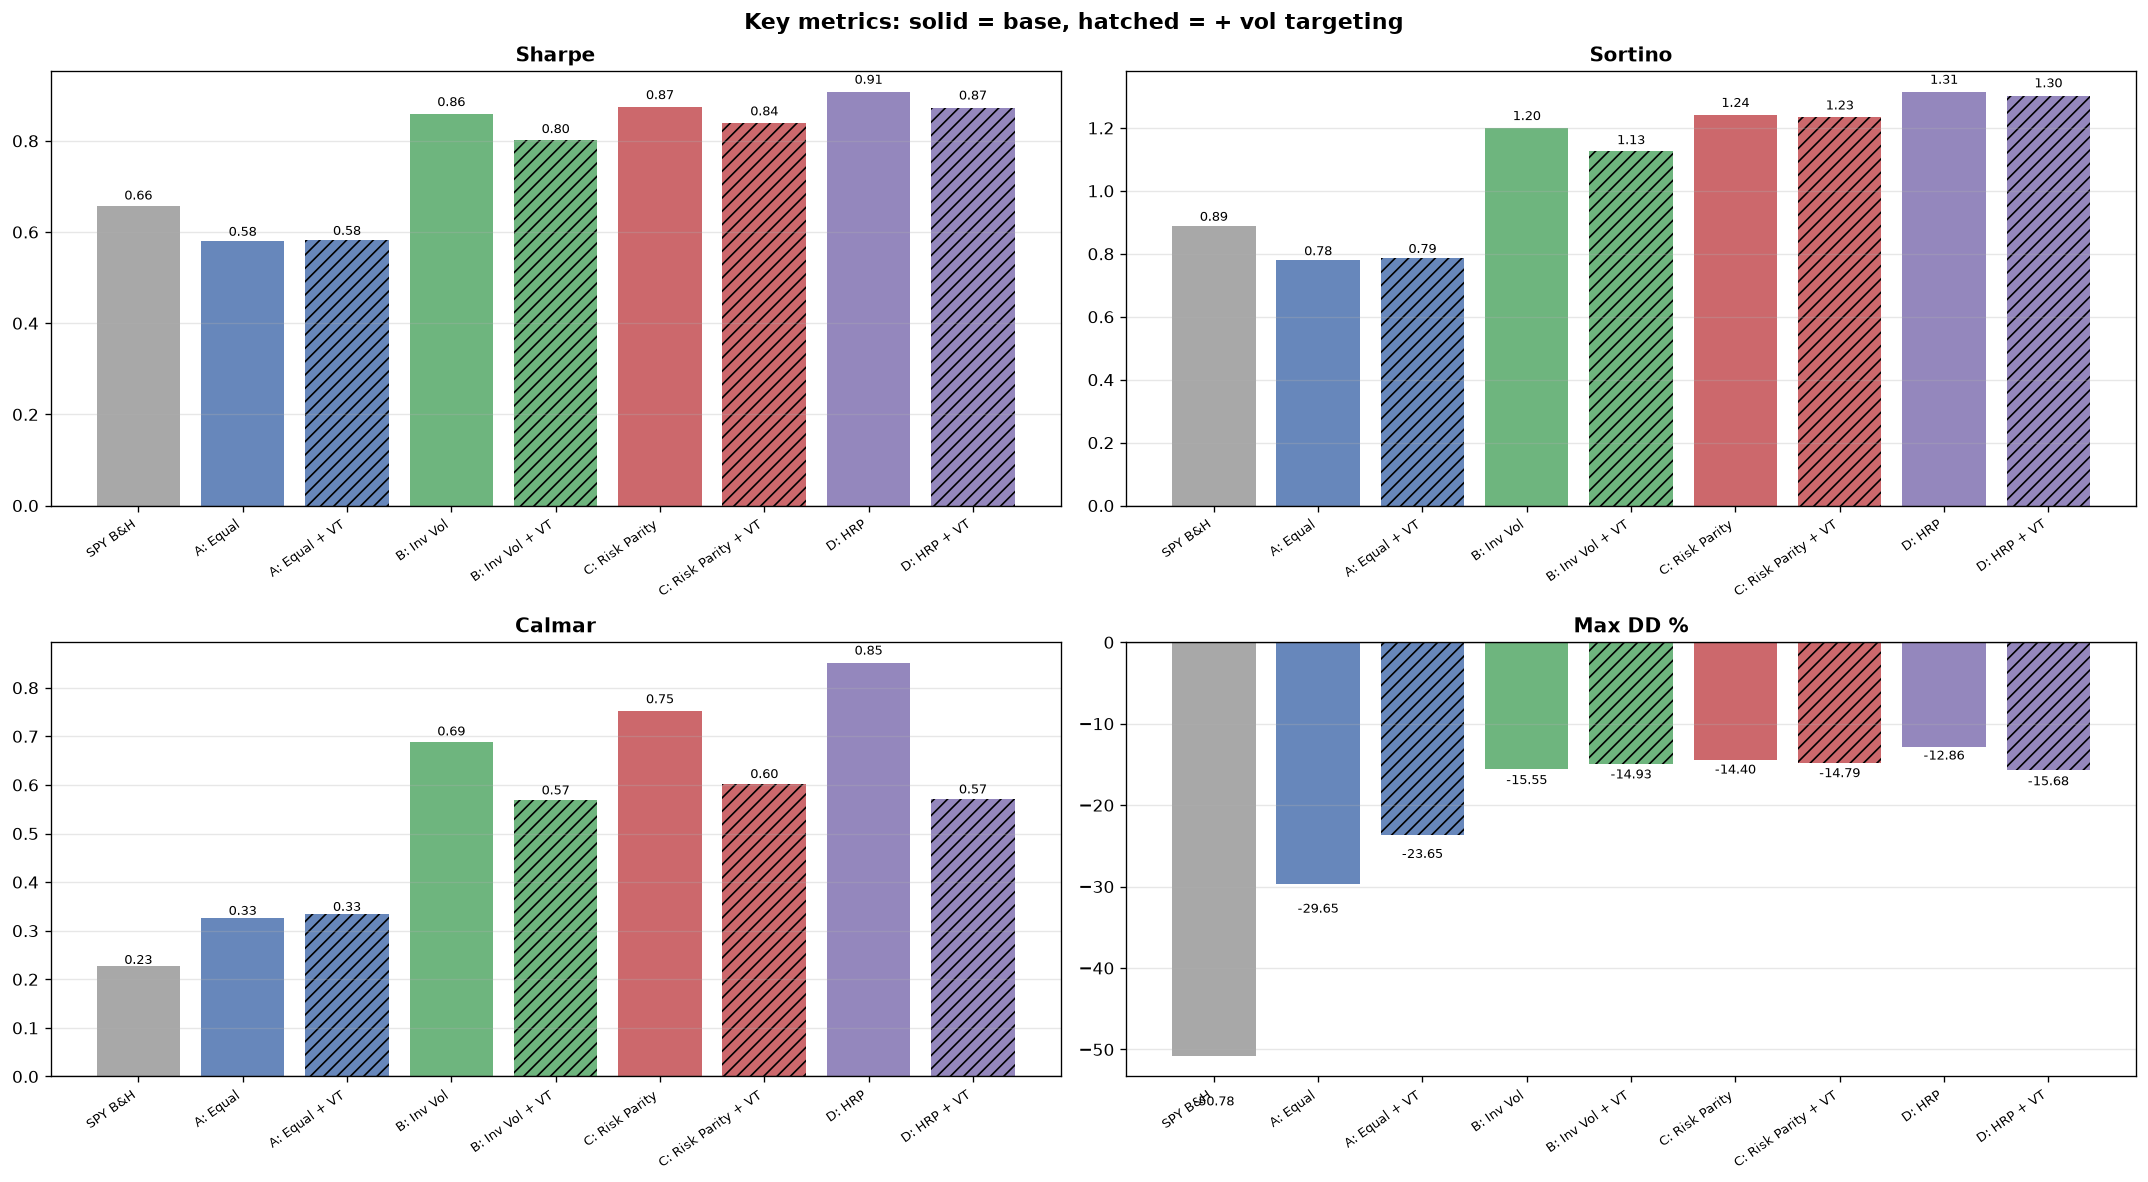

In [6]:
key_metrics = ['Sharpe', 'Sortino', 'Calmar', 'Max DD %']
fig, axes   = plt.subplots(2, 2, figsize=(18, 10))

labels = list(results.keys())
x      = np.arange(len(labels))
bar_colors = [COLORS[l] for l in labels]
alphas     = [0.6 if '+ VT' in l else 0.95 for l in labels]
hatches    = ['///' if '+ VT' in l else '' for l in labels]

for ax, metric in zip(axes.flatten(), key_metrics):
    vals = [results[l]['metrics'].get(metric, np.nan) for l in labels]
    bars = ax.bar(x, vals, color=bar_colors, alpha=0.85)
    for bar, h, v in zip(bars, hatches, vals):
        bar.set_hatch(h)
        if not np.isnan(v):
            y_off = abs(v) * 0.02
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + y_off if v >= 0 else bar.get_height() - y_off * 6,
                    f'{v:.2f}', ha='center', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Key metrics: solid = base, hatched = + vol targeting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Rolling 12-month Sharpe

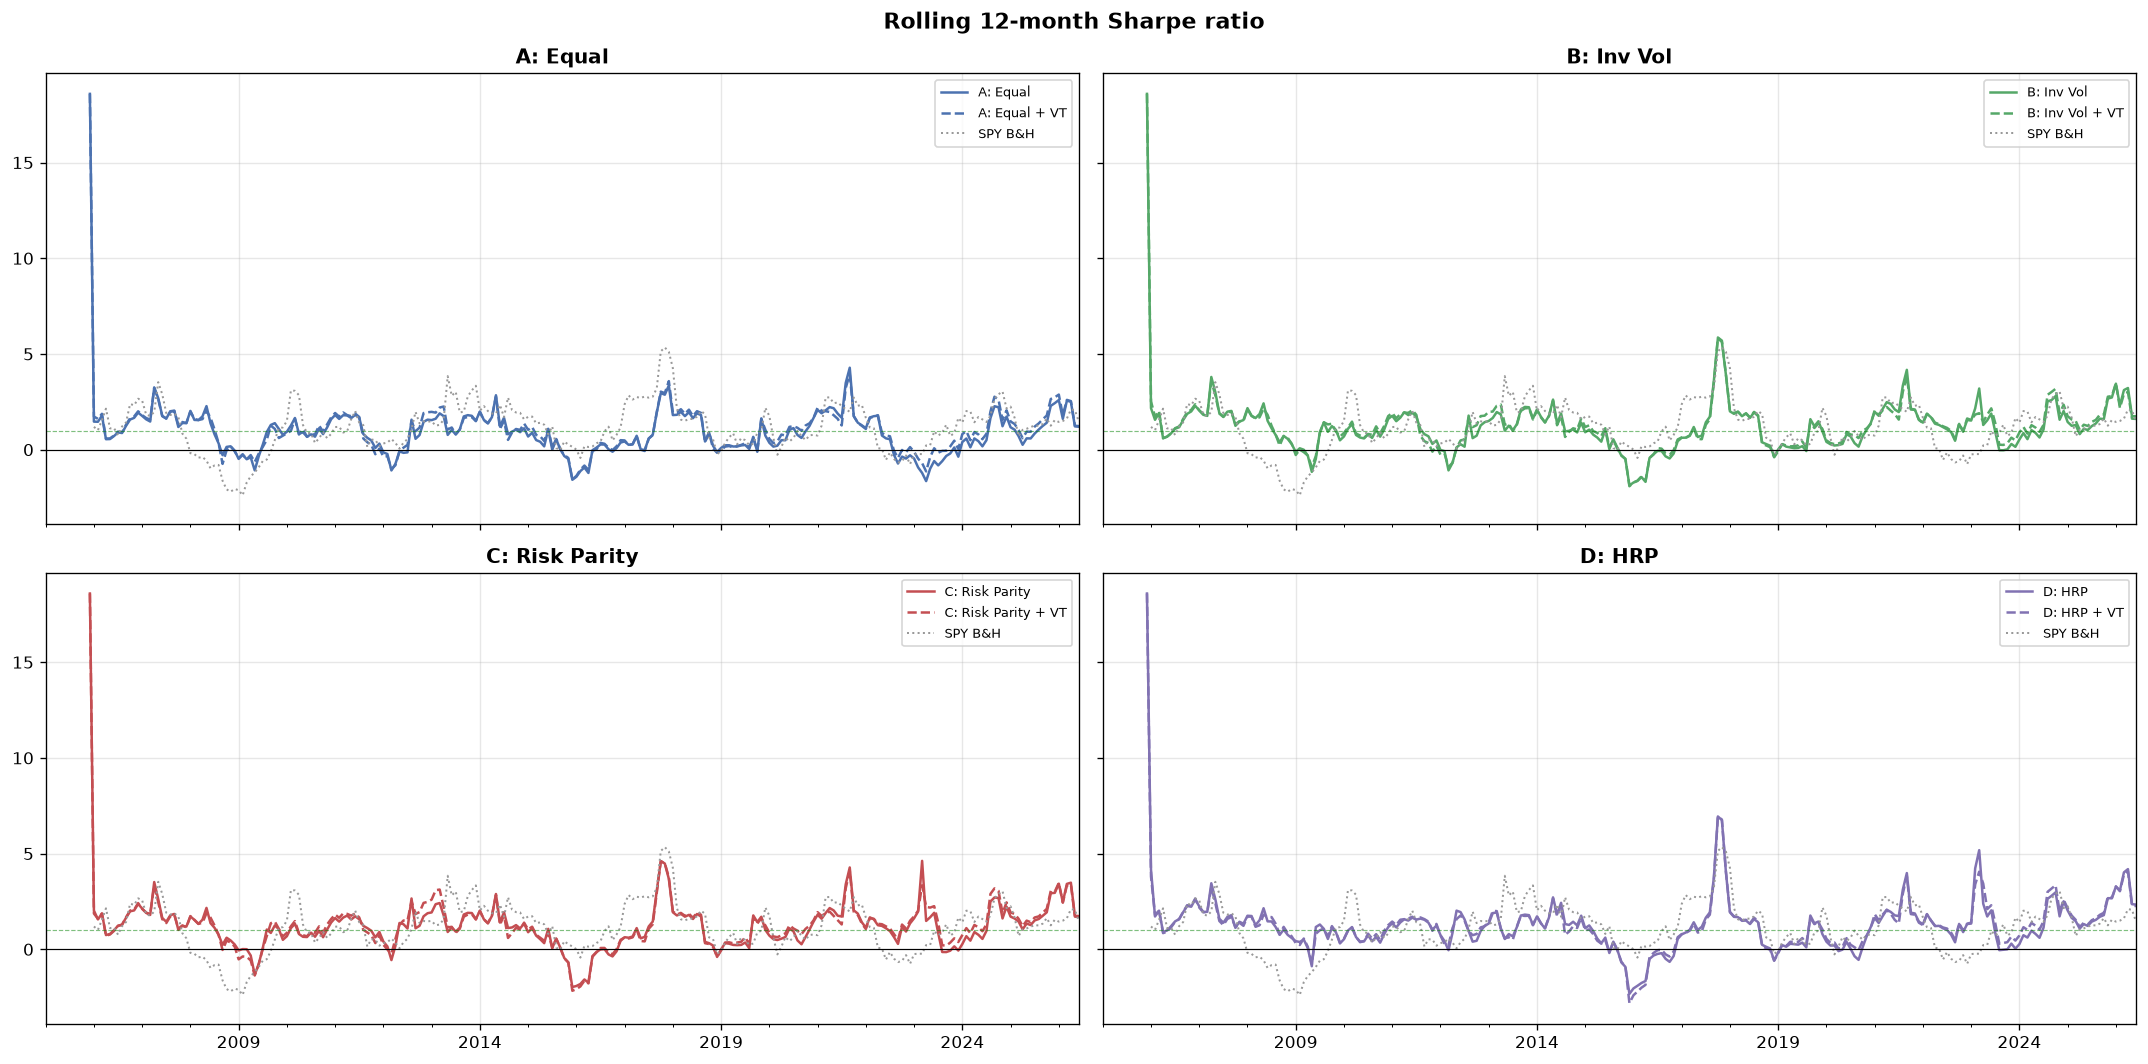

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True, sharey=True)

base_methods = ['A: Equal', 'B: Inv Vol', 'C: Risk Parity', 'D: HRP']

for ax, base in zip(axes.flatten(), base_methods):
    for suffix in ['', ' + VT']:
        label = base + suffix
        if label not in results:
            continue
        r = results[label]['returns']
        roll = (r.rolling(12).mean() / r.rolling(12).std() * np.sqrt(12))
        roll.plot(ax=ax, label=label, color=COLORS[label],
                  linestyle='-' if suffix == '' else '--', linewidth=1.5)

    spy_r = results['SPY B&H']['returns']
    spy_s = (spy_r.rolling(12).mean() / spy_r.rolling(12).std() * np.sqrt(12))
    spy_s.plot(ax=ax, label='SPY B&H', color='#999999', linestyle=':', linewidth=1.2)

    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(1, color='green', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.set_title(base, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Rolling 12-month Sharpe ratio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Vol-targeting: what does it actually do?

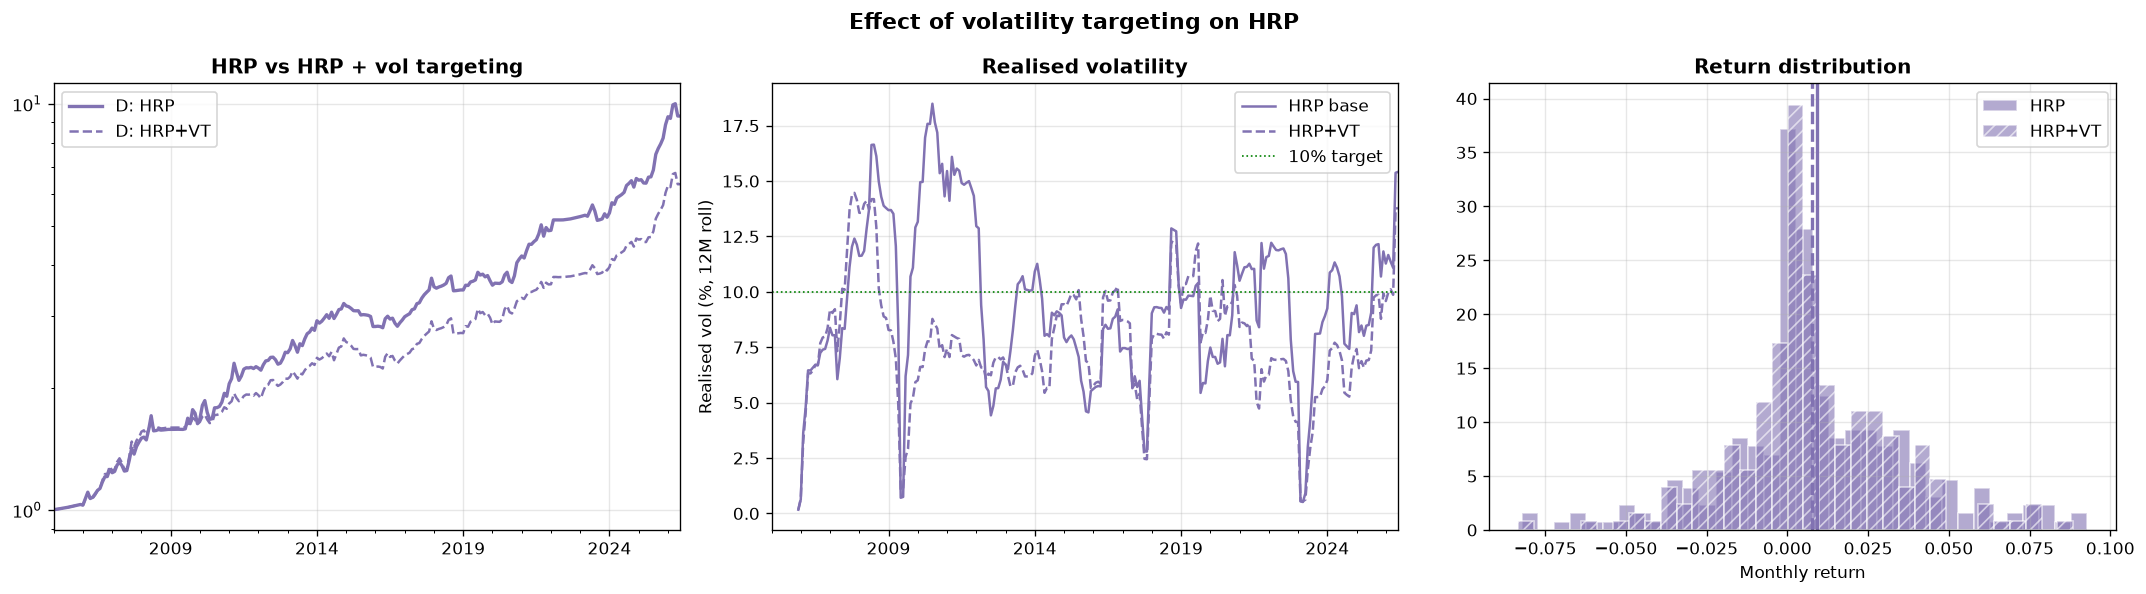

HRP vs HRP+VT:
                D: HRP  D: HRP+VT
Ann Return %    10.940      8.960
Ann Vol %       10.150      8.270
Sharpe           0.907      0.873
Sortino          1.314      1.303
Max DD %       -12.860    -15.680
Calmar           0.851      0.571
VaR 95% %       -3.670     -3.030
CVaR 95% %      -5.770     -4.480
Hit Rate %      69.000     68.600
Best Month %     9.290      8.850
Worst Month %   -8.230     -8.350
Max DD Dur      30.000     32.000
N months       258.000    258.000


In [8]:
# Focus on HRP — with and without VT
r_hrp    = results['D: HRP']['returns']
r_hrp_vt = results['D: HRP + VT']['returns']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Equity
ax = axes[0]
(1 + r_hrp).cumprod().plot(ax=ax, label='D: HRP',       color='#8172B2', linewidth=2)
(1 + r_hrp_vt).cumprod().plot(ax=ax, label='D: HRP+VT', color='#8172B2', linewidth=1.5, linestyle='--')
ax.set_yscale('log')
ax.set_title('HRP vs HRP + vol targeting', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Realised vol comparison
ax = axes[1]
vol12_hrp    = r_hrp.rolling(12).std()    * np.sqrt(12) * 100
vol12_hrp_vt = r_hrp_vt.rolling(12).std() * np.sqrt(12) * 100
vol12_hrp.plot(ax=ax, label='HRP base', color='#8172B2', linewidth=1.5)
vol12_hrp_vt.plot(ax=ax, label='HRP+VT', color='#8172B2', linewidth=1.5, linestyle='--')
ax.axhline(10, color='green', linewidth=1, linestyle=':', label='10% target')
ax.set_ylabel('Realised vol (%, 12M roll)')
ax.set_title('Realised volatility', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Monthly return distribution comparison
ax = axes[2]
ax.hist(r_hrp,    bins=35, alpha=0.6, color='#8172B2', label='HRP',     edgecolor='white', density=True)
ax.hist(r_hrp_vt, bins=35, alpha=0.6, color='#8172B2', label='HRP+VT',  edgecolor='white', density=True, hatch='///')
ax.axvline(r_hrp.mean(),    color='#8172B2', linewidth=2)
ax.axvline(r_hrp_vt.mean(), color='#8172B2', linewidth=2, linestyle='--')
ax.set_xlabel('Monthly return')
ax.set_title('Return distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Effect of volatility targeting on HRP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('HRP vs HRP+VT:')
comp = pd.DataFrame({'D: HRP': results['D: HRP']['metrics'],
                     'D: HRP+VT': results['D: HRP + VT']['metrics']})
print(comp.to_string())

---
## 7. Full metrics table

In [9]:
all_metrics = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
all_metrics.index.name = 'Strategy'

# Highlight best in each column
def highlight_best(col):
    is_max = ['Max DD %', 'Worst Month %', 'VaR 95% %', 'CVaR 95% %', 'Ann Vol %']
    if col.name in is_max:
        best = col.max()
    else:
        best = col.max()
    return ['font-weight: bold; color: darkgreen' if v == best else '' for v in col]

display_cols = ['Ann Return %', 'Ann Vol %', 'Sharpe', 'Sortino',
                'Max DD %', 'Calmar', 'VaR 95% %', 'Hit Rate %', 'Best Month %', 'Worst Month %']

all_metrics[display_cols].round(3)

,Ann Return %,Ann Vol %,Sharpe,Sortino,Max DD %,Calmar,VaR 95% %,Hit Rate %,Best Month %,Worst Month %
Strategy,,,,,,,,,,
SPY B&H,11.54,14.90,0.658,0.887,-50.78,0.227,-6.95,66.5,12.70,-16.52
A: Equal,9.66,13.66,0.580,0.780,-29.65,0.326,-6.31,66.3,11.32,-11.34
A: Equal + VT,7.91,10.61,0.582,0.787,-23.65,0.334,-4.24,66.7,13.08,-12.00
B: Inv Vol,10.69,10.42,0.859,1.201,-15.55,0.688,-4.38,69.0,9.02,-9.91
B: Inv Vol + VT,8.49,8.44,0.801,1.126,-14.93,0.569,-3.33,67.4,9.70,-8.35
C: Risk Parity,10.85,10.43,0.874,1.242,-14.40,0.753,-4.25,69.0,9.12,-9.13
C: Risk Parity + VT,8.90,8.54,0.839,1.234,-14.79,0.602,-3.23,68.6,10.50,-8.18
D: HRP,10.94,10.15,0.907,1.314,-12.86,0.851,-3.67,69.0,9.29,-8.23
D: HRP + VT,8.96,8.27,0.873,1.303,-15.68,0.571,-3.03,68.6,8.85,-8.35


---
## 8. Verdict

In [10]:
verdict = pd.DataFrame([
    {'Strategy': 'SPY B&H',       'Sharpe': 0.658, 'Max DD': '-50.8%', 'Winner?': ''},
    {'Strategy': 'A: Equal',      'Sharpe': 0.580, 'Max DD': '-29.6%', 'Winner?': ''},
    {'Strategy': 'B: Inv Vol',    'Sharpe': 0.859, 'Max DD': '-15.6%', 'Winner?': ''},
    {'Strategy': 'C: Risk Parity','Sharpe': 0.874, 'Max DD': '-14.4%', 'Winner?': ''},
    {'Strategy': 'D: HRP',        'Sharpe': 0.907, 'Max DD': '-12.9%', 'Winner?': '★ Best Sharpe & Max DD'},
    {'Strategy': 'D: HRP + VT',   'Sharpe': 0.873, 'Max DD': '-15.7%',
     'Winner?': 'VT reduces return more than risk — HRP already risk-managed'},
]).set_index('Strategy')

print(verdict.to_string())
print()
print('Finding: Vol targeting helps Equal Weight (adds risk control it lacks).')
print('         Vol targeting HURTS HRP (which already targets risk via correlation structure).')
print('         Recommended production strategy: Momentum + Top-5 + 200DMA + HRP.')

                Sharpe  Max DD                                                      Winner?
Strategy                                                                                   
SPY B&H          0.658  -50.8%                                                             
A: Equal         0.580  -29.6%                                                             
B: Inv Vol       0.859  -15.6%                                                             
C: Risk Parity   0.874  -14.4%                                                             
D: HRP           0.907  -12.9%                                       ★ Best Sharpe & Max DD
D: HRP + VT      0.873  -15.7%  VT reduces return more than risk — HRP already risk-managed

Finding: Vol targeting helps Equal Weight (adds risk control it lacks).
         Vol targeting HURTS HRP (which already targets risk via correlation structure).
         Recommended production strategy: Momentum + Top-5 + 200DMA + HRP.
